In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

df1 = pd.read_csv(r"C:\\Users\\belzs\\Documents\\DATA ANALYST\\Bike Store\\brands.csv")

df1

,brand_id,brand_name
0,1,Electra
1,2,Haro
2,3,Heller
3,4,Pure Cycles
4,5,Ritchey
5,6,Strider
6,7,Sun Bicycles
7,8,Surly
8,9,Trek


In [2]:
df2 = pd.read_csv(r"C:\\Users\\belzs\\Documents\\DATA ANALYST\\Bike Store\\Products.csv")

df2.head()

,product_id,product_name,brand_id,category_id,model_year,list_price
0,1,Trek 820 - 2016,9,6,2016,379.99
1,2,Ritchey Timberwolf Frameset - 2016,5,6,2016,749.99
2,3,Surly Wednesday Frameset - 2016,8,6,2016,999.99
3,4,Trek Fuel EX 8 29 - 2016,9,6,2016,2899.99
4,5,Heller Shagamaw Frame - 2016,3,6,2016,1320.99


In [3]:
df3 = df2.merge(df1, how = 'inner', on = 'brand_id')

df3.head()



,product_id,product_name,brand_id,category_id,model_year,list_price,brand_name
0,1,Trek 820 - 2016,9,6,2016,379.99,Trek
1,4,Trek Fuel EX 8 29 - 2016,9,6,2016,2899.99,Trek
2,7,Trek Slash 8 27.5 - 2016,9,6,2016,3999.99,Trek
3,8,Trek Remedy 29 Carbon Frameset - 2016,9,6,2016,1799.99,Trek
4,9,Trek Conduit+ - 2016,9,5,2016,2999.99,Trek


In [4]:
df_cat = pd.read_csv(r"C:\\Users\\belzs\\Documents\\DATA ANALYST\\Bike Store\\categories.csv")

df_cat.head()

df5 = df3.merge(df_cat, how = 'inner', on = 'category_id')
df5.head()


,product_id,product_name,brand_id,category_id,model_year,list_price,brand_name,category_name
0,1,Trek 820 - 2016,9,6,2016,379.99,Trek,Mountain Bikes
1,4,Trek Fuel EX 8 29 - 2016,9,6,2016,2899.99,Trek,Mountain Bikes
2,7,Trek Slash 8 27.5 - 2016,9,6,2016,3999.99,Trek,Mountain Bikes
3,8,Trek Remedy 29 Carbon Frameset - 2016,9,6,2016,1799.99,Trek,Mountain Bikes
4,29,Trek X-Caliber 8 - 2017,9,6,2017,999.99,Trek,Mountain Bikes


In [5]:
df6 = df2.merge(df1, how = 'inner', on ='brand_id')\
   .merge(df_cat, how = 'inner', on ='category_id')
df6 = df6.drop(['brand_id', 'category_id'], axis = 1)
df6.head(10)

,product_id,product_name,model_year,list_price,brand_name,category_name
0,1,Trek 820 - 2016,2016,379.99,Trek,Mountain Bikes
1,4,Trek Fuel EX 8 29 - 2016,2016,2899.99,Trek,Mountain Bikes
2,7,Trek Slash 8 27.5 - 2016,2016,3999.99,Trek,Mountain Bikes
3,8,Trek Remedy 29 Carbon Frameset - 2016,2016,1799.99,Trek,Mountain Bikes
4,29,Trek X-Caliber 8 - 2017,2017,999.99,Trek,Mountain Bikes
5,32,Trek Farley Alloy Frameset - 2017,2017,469.99,Trek,Mountain Bikes
6,34,Trek Session DH 27.5 Carbon Frameset - 2017,2017,469.99,Trek,Mountain Bikes
7,39,Trek Stache 5 - 2017,2017,1499.99,Trek,Mountain Bikes
8,40,Trek Fuel EX 9.8 29 - 2017,2017,4999.99,Trek,Mountain Bikes
9,42,Trek Fuel EX 5 27.5 Plus - 2017,2017,2299.99,Trek,Mountain Bikes


In [6]:
df6['product_name'].unique()
hx = df6['product_name'].str.replace(r"\s*-\s*\d{4}","", regex = True)
hx.unique()

array(['Trek 820', 'Trek Fuel EX 8 29', 'Trek Slash 8 27.5',
       'Trek Remedy 29 Carbon Frameset', 'Trek X-Caliber 8',
       'Trek Farley Alloy Frameset',
       'Trek Session DH 27.5 Carbon Frameset', 'Trek Stache 5',
       'Trek Fuel EX 9.8 29', 'Trek Fuel EX 5 27.5 Plus',
       'Trek Fuel EX 9.8 27.5 Plus', 'Trek Remedy 9.8', 'Trek Marlin 5',
       'Trek Marlin 6', 'Trek Marlin 7/2018', 'Trek Ticket S Frame',
       "Trek Kids' Neko", 'Trek Fuel EX 7 29',
       'Trek Farley Carbon Frameset', "Trek Kids' Dual Sport",
       'Trek X-Caliber 7', 'Trek Stache Carbon Frameset',
       'Trek Procal AL Frameset', 'Trek Procaliber Frameset',
       'Trek Remedy 27.5 C Frameset', 'Trek X-Caliber Frameset',
       'Trek Procaliber 6', 'Trek Fuel EX 5 Plus', 'Trek Remedy 7 27.5',
       'Trek Remedy 9.8 27.5', 'Trek Fuel EX 8 29 XT',
       'Ritchey Timberwolf Frameset', 'Surly Wednesday Frameset',
       'Surly Ice Cream Truck Frameset', 'Surly Big Dummy Frameset',
       'Surly Karat

In [7]:
df6['product_name'] = hx
df6.head()

,product_id,product_name,model_year,list_price,brand_name,category_name
0,1,Trek 820,2016,379.99,Trek,Mountain Bikes
1,4,Trek Fuel EX 8 29,2016,2899.99,Trek,Mountain Bikes
2,7,Trek Slash 8 27.5,2016,3999.99,Trek,Mountain Bikes
3,8,Trek Remedy 29 Carbon Frameset,2016,1799.99,Trek,Mountain Bikes
4,29,Trek X-Caliber 8,2017,999.99,Trek,Mountain Bikes


In [8]:
df_ord = pd.read_csv(r"C:\\Users\\belzs\\Documents\\DATA ANALYST\\Bike Store\\orders.csv")
df_ord.tail()

,order_id,customer_id,order_status,order_date,required_date,shipped_date,store_id,staff_id
1610,1611,6,3,2018-09-06,2018-09-06,NaN,2,7
1611,1612,3,3,2018-10-21,2018-10-21,NaN,1,3
1612,1613,1,3,2018-11-18,2018-11-18,NaN,2,6
1613,1614,135,3,2018-11-28,2018-11-28,NaN,3,8
1614,1615,136,3,2018-12-28,2018-12-28,NaN,3,8


In [9]:
df_cus = pd.read_csv(r"C:\\Users\\belzs\\Documents\\DATA ANALYST\\Bike Store\\customers.csv")
df_cus['name'] = df_cus['first_name'] + ' ' + df_cus['last_name']

cols = list(df_cus.columns)
cols.remove('name')
idx = cols.index('customer_id') + 1
cols.insert(idx, 'name')
df_cus = df_cus[cols]

df_cus = df_cus.drop(['first_name', 'last_name'], axis= 1)
df_cus = df_cus.fillna('No Number')
df_cus['street'] = df_cus['street'].str.replace(r"\s*\.\s*$", "", regex=True)

df_cus.columns = df_cus.columns.str.replace('name', 'customers_name')

df_cus.tail()

,customer_id,customers_name,phone,email,street,city,state,zip_code
1440,1441,Jamaal Morrison,No Number,jamaal.morrison@msn.com,796 SE. Nut Swamp St,Staten Island,NY,10301
1441,1442,Cassie Cline,No Number,cassie.cline@gmail.com,947 Lafayette Drive,Brooklyn,NY,11201
1442,1443,Lezlie Lamb,No Number,lezlie.lamb@gmail.com,401 Brandywine Street,Central Islip,NY,11722
1443,1444,Ivette Estes,No Number,ivette.estes@gmail.com,88 N. Canterbury Ave,Canandaigua,NY,14424
1444,1445,Ester Acevedo,No Number,ester.acevedo@gmail.com,671 Miles Court,San Lorenzo,CA,94580


In [10]:
df_stores = pd.read_csv(r"C:\\Users\\belzs\\Documents\\DATA ANALYST\\Bike Store\\stores.csv")
df_stores.isna().sum()

store_id      0
store_name    0
phone         0
email         0
street        0
city          0
state         0
zip_code      0
dtype: int64

In [11]:
df_staffs = pd.read_csv(r"C:\\Users\\belzs\\Documents\\DATA ANALYST\\Bike Store\\staffs.csv")
df_staffs.head()
df_staffs['name'] = df_staffs['first_name'] + " " + df_staffs['last_name']
cols = list(df_staffs.columns)
cols.remove('name')
idx = cols.index('staff_id') + 1
cols.insert(idx, 'name')
df_staffs = df_staffs[cols]

df_staffs = df_staffs.drop(['first_name', 'last_name'], axis= True)

df_staffs.columns = df_staffs.columns.str.replace('name' ,'staffs_name')

df_staffs.head()


,staff_id,staffs_name,email,phone,active,store_id,manager_id
0,1,Fabiola Jackson,fabiola.jackson@bikes.shop,(831) 555-5554,1,1,NaN
1,2,Mireya Copeland,mireya.copeland@bikes.shop,(831) 555-5555,1,1,1.0
2,3,Genna Serrano,genna.serrano@bikes.shop,(831) 555-5556,1,1,2.0
3,4,Virgie Wiggins,virgie.wiggins@bikes.shop,(831) 555-5557,1,1,2.0
4,5,Jannette David,jannette.david@bikes.shop,(516) 379-4444,1,2,1.0


In [12]:
dfx  = df_ord.merge(df_cus[['customer_id','customers_name','phone','email','city','state']], on= 'customer_id', how= 'inner')\
      .merge(df_stores[['store_id','store_name']], on= 'store_id', how= 'inner')\
      .merge(df_staffs[['staff_id','staffs_name']], on= 'staff_id', how= 'inner')

dfx = dfx.drop(['customer_id', 'store_id','staff_id'], axis= True)
dfx.head(10)

,order_id,order_status,order_date,required_date,shipped_date,customers_name,phone,email,city,state,store_name,staffs_name
0,1,4,2016-01-01,2016-01-03,2016-01-03,Johnathan Velazquez,No Number,johnathan.velazquez@hotmail.com,Pleasanton,CA,Santa Cruz Bikes,Mireya Copeland
1,1518,1,2018-04-11,2018-04-11,NaN,Nova Hess,No Number,nova.hess@msn.com,Duarte,CA,Santa Cruz Bikes,Mireya Copeland
2,9,4,2016-01-05,2016-01-08,2016-01-08,Neil Mccall,No Number,neil.mccall@gmail.com,San Carlos,CA,Santa Cruz Bikes,Mireya Copeland
3,1565,2,2018-04-21,2018-04-21,NaN,Neil Mccall,No Number,neil.mccall@gmail.com,San Carlos,CA,Santa Cruz Bikes,Mireya Copeland
4,12,4,2016-01-06,2016-01-08,2016-01-09,Marvin Mullins,(619) 635-2027,marvin.mullins@aol.com,San Diego,CA,Santa Cruz Bikes,Mireya Copeland
5,19,4,2016-01-14,2016-01-17,2016-01-16,Norine Huffman,No Number,norine.huffman@aol.com,Encino,CA,Santa Cruz Bikes,Mireya Copeland
6,20,4,2016-01-14,2016-01-16,2016-01-17,Randee Pitts,No Number,randee.pitts@msn.com,Canyon Country,CA,Santa Cruz Bikes,Mireya Copeland
7,22,4,2016-01-16,2016-01-18,2016-01-17,Tangela Hurley,No Number,tangela.hurley@msn.com,Campbell,CA,Santa Cruz Bikes,Mireya Copeland
8,23,4,2016-01-16,2016-01-19,2016-01-19,Drucilla Gilliam,No Number,drucilla.gilliam@hotmail.com,Santa Clara,CA,Santa Cruz Bikes,Mireya Copeland
9,52,4,2016-02-03,2016-02-04,2016-02-05,Twana Arnold,(657) 988-1904,twana.arnold@msn.com,Anaheim,CA,Santa Cruz Bikes,Mireya Copeland


In [13]:
df_item = pd.read_csv(r"C:\\Users\\belzs\\Documents\\DATA ANALYST\\Bike Store\\order_items.csv")
df_item.head()

dfg = df_item.merge(dfx,how='inner', on='order_id')

dfg.duplicated()
dfg.isna().sum()



dfh = dfg.merge(df6[['product_id', 'product_name', 'brand_name', 'category_name']], on = 'product_id', how = 'inner')

move = ['quantity', 'list_price', 'discount']
cols = [col for col in dfh.columns if col not in move] + move
dfh = dfh[cols]
dfh = dfh.drop([ 'item_id', 'product_id'], axis= 1)


depan = ['order_id','customers_name', 'phone', 'email', 'city', 'state', 'product_name', 'brand_name', 'category_name','store_name','staffs_name']
cols = depan + [col for col in dfh.columns if col not in depan]
dfh = dfh[cols]
dfh.head()

dfh['total'] = (dfh['quantity'] * dfh['list_price']*(1 - dfh['discount'] )).round(2)

dfh.head()

,order_id,customers_name,phone,email,city,state,product_name,brand_name,category_name,store_name,staffs_name,order_status,order_date,required_date,shipped_date,quantity,list_price,discount,total
0,1,Johnathan Velazquez,No Number,johnathan.velazquez@hotmail.com,Pleasanton,CA,Electra Townie Original 7D EQ - Women's,Electra,Cruisers Bicycles,Santa Cruz Bikes,Mireya Copeland,4,2016-01-01,2016-01-03,2016-01-03,1,599.99,0.20,479.99
1,2,Jaqueline Cummings,No Number,jaqueline.cummings@hotmail.com,Huntington Station,NY,Electra Townie Original 7D EQ - Women's,Electra,Cruisers Bicycles,Baldwin Bikes,Marcelene Boyer,4,2016-01-01,2016-01-04,2016-01-03,1,599.99,0.07,557.99
2,3,Joshua Robertson,No Number,joshua.robertson@gmail.com,Patchogue,NY,Electra Townie Original 7D EQ - Women's,Electra,Cruisers Bicycles,Baldwin Bikes,Venita Daniel,4,2016-01-02,2016-01-05,2016-01-03,1,599.99,0.05,569.99
3,6,Sharyn Hopkins,No Number,sharyn.hopkins@hotmail.com,Baldwinsville,NY,Electra Townie Original 7D EQ - Women's,Electra,Cruisers Bicycles,Baldwin Bikes,Marcelene Boyer,4,2016-01-04,2016-01-07,2016-01-05,1,599.99,0.10,539.99
4,8,Leslie Higgins,No Number,leslie.higgins@hotmail.com,Saratoga Springs,NY,Electra Townie Original 7D EQ - Women's,Electra,Cruisers Bicycles,Baldwin Bikes,Venita Daniel,4,2016-01-04,2016-01-05,2016-01-05,2,599.99,0.07,1115.98


In [14]:
dfh['order_date'] = pd.to_datetime(dfh['order_date'])
dfh['required_date'] = pd.to_datetime(dfh['required_date'])
dfh['shipped_date'] = pd.to_datetime(dfh['shipped_date'])
dfh.info()

dfh.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4722 entries, 0 to 4721
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        4722 non-null   int64         
 1   customers_name  4722 non-null   object        
 2   phone           4722 non-null   object        
 3   email           4722 non-null   object        
 4   city            4722 non-null   object        
 5   state           4722 non-null   object        
 6   product_name    4722 non-null   object        
 7   brand_name      4722 non-null   object        
 8   category_name   4722 non-null   object        
 9   store_name      4722 non-null   object        
 10  staffs_name     4722 non-null   object        
 11  order_status    4722 non-null   int64         
 12  order_date      4722 non-null   datetime64[ns]
 13  required_date   4722 non-null   datetime64[ns]
 14  shipped_date    4214 non-null   datetime64[ns]
 15  quan

,order_id,customers_name,phone,email,city,state,product_name,brand_name,category_name,store_name,staffs_name,order_status,order_date,required_date,shipped_date,quantity,list_price,discount,total
0,1,Johnathan Velazquez,No Number,johnathan.velazquez@hotmail.com,Pleasanton,CA,Electra Townie Original 7D EQ - Women's,Electra,Cruisers Bicycles,Santa Cruz Bikes,Mireya Copeland,4,2016-01-01,2016-01-03,2016-01-03,1,599.99,0.20,479.99
1,2,Jaqueline Cummings,No Number,jaqueline.cummings@hotmail.com,Huntington Station,NY,Electra Townie Original 7D EQ - Women's,Electra,Cruisers Bicycles,Baldwin Bikes,Marcelene Boyer,4,2016-01-01,2016-01-04,2016-01-03,1,599.99,0.07,557.99
2,3,Joshua Robertson,No Number,joshua.robertson@gmail.com,Patchogue,NY,Electra Townie Original 7D EQ - Women's,Electra,Cruisers Bicycles,Baldwin Bikes,Venita Daniel,4,2016-01-02,2016-01-05,2016-01-03,1,599.99,0.05,569.99
3,6,Sharyn Hopkins,No Number,sharyn.hopkins@hotmail.com,Baldwinsville,NY,Electra Townie Original 7D EQ - Women's,Electra,Cruisers Bicycles,Baldwin Bikes,Marcelene Boyer,4,2016-01-04,2016-01-07,2016-01-05,1,599.99,0.10,539.99
4,8,Leslie Higgins,No Number,leslie.higgins@hotmail.com,Saratoga Springs,NY,Electra Townie Original 7D EQ - Women's,Electra,Cruisers Bicycles,Baldwin Bikes,Venita Daniel,4,2016-01-04,2016-01-05,2016-01-05,2,599.99,0.07,1115.98


In [15]:
#total revenue
total_sales = dfh['total'].sum().round(2)
print(total_sales)

#Jadi total revenue dari seluruh transaksi adalah 7689109.71

7689109.71


In [16]:
#top 10 konsumen berdasarkan total_sales
top_consumer = dfh.groupby('customers_name')['total'].sum().sort_values(ascending = 0).head(10)
print(top_consumer)

customers_name
Sharyn Hopkins     34807.93
Pamelia Newman     33634.24
Abby Gamble        32802.99
Lyndsey Bean       32675.06
Emmitt Sanchez     31925.87
Melanie Hayes      31913.68
Debra Burks        27888.17
Elinore Aguilar    25636.43
Corrina Sawyer     25612.69
Shena Carter       24890.62
Name: total, dtype: float64


In [17]:
# % Sales Growth 
sales_bulanan = dfh.resample('M', on='order_date')['total'].sum().round(2)
sales_bulanan = sales_bulanan.reset_index()
sales_bulanan['sales_growth%'] = sales_bulanan['total'].pct_change()*100
print(sales_bulanan)

   order_date      total  sales_growth%
0  2016-01-31  215146.23            NaN
1  2016-02-29  156112.11     -27.439068
2  2016-03-31  180600.13      15.686176
3  2016-04-30  167143.90      -7.450842
4  2016-05-31  205269.82      22.810237
5  2016-06-30  210561.95       2.578134
6  2016-07-31  199556.61      -5.226652
7  2016-08-31  225657.16      13.079271
8  2016-09-30  273091.37      21.020476
9  2016-10-31  212077.86     -22.341794
10 2016-11-30  182329.24     -14.027216
11 2016-12-31  199829.79       9.598323
12 2017-01-31  285616.26      42.929770
13 2017-02-28  312923.47       9.560804
14 2017-03-31  308911.60      -1.282061
15 2017-04-30  227290.63     -26.422112
16 2017-05-31  268232.99      18.013219
17 2017-06-30  378865.34      41.244871
18 2017-07-31  229995.14     -39.293697
19 2017-08-31  290553.17      26.330135
20 2017-09-30  293405.03       0.981528
21 2017-10-31  310328.02       5.767791
22 2017-11-30  281577.65      -9.264510
23 2017-12-31  259505.76      -7.838651


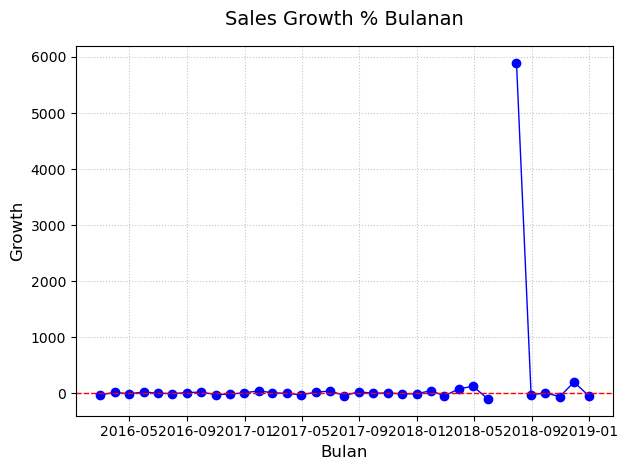

In [18]:
plt.figure()
plt.plot(sales_bulanan['order_date'][1:], sales_bulanan['sales_growth%'][1:], marker = 'o' , linestyle = '-' , color = 'b' , linewidth = 1)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Sales Growth % Bulanan', fontsize= 14, pad= 15)
plt.xlabel('Bulan', fontsize= 12 )
plt.ylabel('Growth', fontsize = 12)
plt.grid(True, linestyle = ':', alpha = 0.7)
plt.tight_layout()
plt.show()

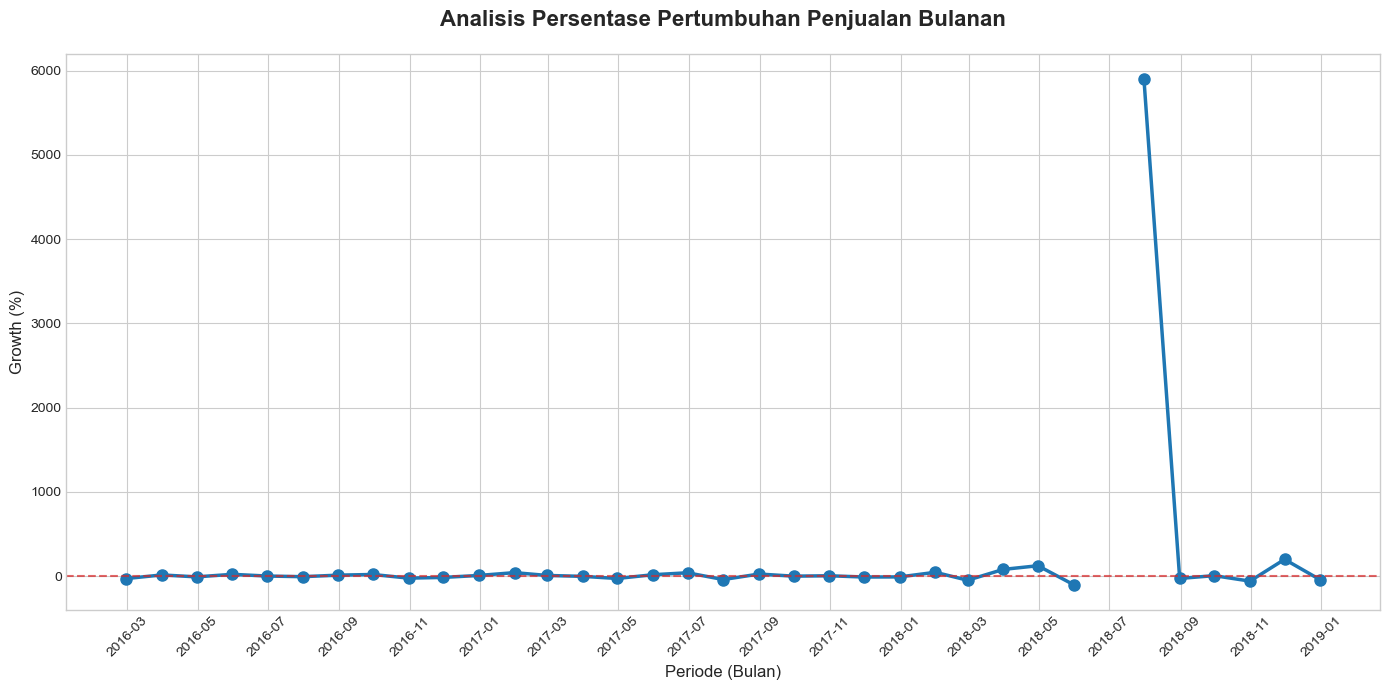

In [19]:
import matplotlib.dates as mdates

# 1. Setup Ukuran dan Style
plt.figure(figsize=(14, 7))
plt.style.use('seaborn-v0_8-whitegrid') # Opsional: agar tampilan lebih modern

# 2. Plot Data (Menghilangkan baris pertama yang NaN)
data_plot = sales_bulanan.dropna()
plt.plot(data_plot['order_date'], data_plot['sales_growth%'], 
         marker='o', markersize=8, linestyle='-', color='#1f77b4', linewidth=2.5, label='Growth %')

# 3. Tambahkan Garis Baseline (0%)
plt.axhline(0, color='#d62728', linestyle='--', linewidth=1.5, alpha=0.7)

# 4. Format Sumbu X agar tidak menumpuk
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2)) # Munculkan label tiap 2 bulan
plt.xticks(rotation=45)

# 5. Tambahkan Judul dan Label
plt.title('Analisis Persentase Pertumbuhan Penjualan Bulanan', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Periode (Bulan)', fontsize=12)
plt.ylabel('Growth (%)', fontsize=12)

# 6. Tambahkan Anotasi untuk Lonjakan Tertinggi (Opsional)
max_growth = data_plot['sales_growth%'].max()
max_date = data_plot.loc[data_plot['sales_growth%'].idxmax(), 'order_date']
plt.annotate(f'Peak: {max_growth:.2f}%', 
             xy=(max_date, max_growth), xytext=(10, 10),
             textcoords='offset points', arrowprops=dict(arrowstyle='->', color='black'))

plt.tight_layout()
plt.show()

In [20]:
# average order value
total_order = dfh['order_id'].nunique()

aov = (total_sales / total_order).round(2)

print(aov)

# Jadi rata rata konsumen belanja per transaksi adalah 4761.06

4761.06


In [21]:
#Revenue per kustomer
total_konsumen = dfh['customers_name'].nunique()
rpk = (total_sales / total_konsumen).round(2)
rpk



5324.87

In [22]:
#rpk per bulan
bulan = dfh.groupby(pd.Grouper(key='order_date', freq='M')).agg({
    'total' : 'sum',
    'customers_name' : 'nunique'
}).reset_index()

bulan['rpk'] = bulan['total'] / bulan['customers_name']

bulan.round(2)

,order_date,total,customers_name,rpk
0,2016-01-31,215146.23,50,4302.92
1,2016-02-29,156112.11,49,3185.96
2,2016-03-31,180600.13,55,3283.64
3,2016-04-30,167143.90,42,3979.62
4,2016-05-31,205269.82,51,4024.90
5,2016-06-30,210561.95,45,4679.15
6,2016-07-31,199556.61,50,3991.13
7,2016-08-31,225657.16,63,3581.86
8,2016-09-30,273091.37,66,4137.75
9,2016-10-31,212077.86,64,3313.72


In [23]:
#rpk per tahun
Tahun = dfh.groupby(pd.Grouper(key='order_date', freq='Y')).agg({
    'total' : 'sum',
    'customers_name' : 'nunique'
}).reset_index()
Tahun['rpk'] = Tahun['total'] / Tahun['customers_name']
Tahun.round(2)
# terjadi peningkatan dari konsumen setiap tahun,  pada tahun 2016 hingga 2017 lebih stabil, pada 2018 awal terjadi peningkatan yang signifikan,
# pada bulan mei 2018 terdapat masalah / data issue lalu setelah mei 2018 rpk sudah tidak normal dikarenakan jumlah konsumen yang menjadi sangat sedikit

,order_date,total,customers_name,rpk
0,2016-12-31,2427376.17,625,3883.80
1,2017-12-31,3447205.06,684,5039.77
2,2018-12-31,1814528.48,270,6720.48


In [24]:
# top 10 selling product by quantity
top_product = dfh.groupby('product_name')['quantity'].sum().sort_values(ascending = 0).head(10)
top_product

#top 10 selling product by revenue
rvnprod = dfh.groupby('product_name')['total'].sum().sort_values(ascending = 0).head(10)
rvnprod

product_name
Trek Slash 8 27.5                 555558.46
Trek Conduit+                     407056.48
Trek Fuel EX 8 29                 382904.52
Surly Straggler 650b              235068.03
Trek Domane SLR 6 Disc            222034.55
Surly Straggler                   215280.02
Trek Remedy 29 Carbon Frameset    203380.75
Trek Powerfly 8 FS Plus           188249.59
Trek Madone 9.2                   175899.61
Trek Silque SLR 8 Women's         174524.71
Name: total, dtype: float64

In [25]:
# Persentase kontribusi product ke total revenue 
rvnprod1 = dfh.groupby('product_name')['total'].sum().reset_index()
rvnprod1['kontribusi'] = (rvnprod1['total']/total_sales * 100).round(2)
rvnprod1.sort_values('kontribusi', ascending= 0)

,product_name,total,kontribusi
250,Trek Slash 8 27.5,555558.46,7.23
153,Trek Conduit+,407056.48,5.29
202,Trek Fuel EX 8 29,382904.52,4.98
142,Surly Straggler 650b,235068.03,3.06
184,Trek Domane SLR 6 Disc,222034.55,2.89
...,...,...,...
42,Electra Straight 8 1 (16-inch) - Boy's,265.99,0.00
53,Electra Tiger Shark 3i (20-inch) - Boys',332.99,0.00
84,"Electra Treasure 3i 20""",295.99,0.00
40,Electra Soft Serve 1 (16-inch) - Girl's,223.99,0.00


In [26]:
dfh['product_name'].nunique()

265

In [27]:
#jumlah barang terjual
sold = dfh['quantity'].sum()
sold

7078

In [28]:
#Customer Retention Rate

dfh['month'] = dfh['order_date'].dt.to_period('M')
konsumen_bulanan = dfh.groupby('month')['customers_name'].apply(set)

retention = []
months = sorted(konsumen_bulanan.index)

for i in range(1, len(months)):
    prev_customers = konsumen_bulanan[months[i-1]]
    curr_customers = konsumen_bulanan[months[i]]
    
    retained = len(prev_customers & curr_customers)
    total_prev = len(prev_customers)

    rate = retained / total_prev if total_prev > 0 else 0

    retention.append(
        {
            'month' : str(months[i]),
            'retention_rate' : rate * 100
        }
    )

retention_df = pd.DataFrame(retention)
retention_df.round(2)


,month,retention_rate
0,2016-02,0.00
1,2016-03,0.00
2,2016-04,0.00
3,2016-05,0.00
4,2016-06,0.00
5,2016-07,0.00
6,2016-08,0.00
7,2016-09,3.17
8,2016-10,0.00
9,2016-11,0.00


In [29]:
#Customer Churn Rate

churn = []

for i in range(1, len(months)):
    prev_customers = konsumen_bulanan[months[i-1]]
    curr_customers = konsumen_bulanan[months[i]]

    churned = len(prev_customers-curr_customers)
    total_prev = len(prev_customers)
    rate = churned/total_prev if total_prev > 0 else 0
    churn.append({
        'month' : str(months[i]),
        'churn_rate' : rate * 100
    })
churn_df = pd.DataFrame(churn)
print(churn_df)

      month  churn_rate
0   2016-02  100.000000
1   2016-03  100.000000
2   2016-04  100.000000
3   2016-05  100.000000
4   2016-06  100.000000
5   2016-07  100.000000
6   2016-08  100.000000
7   2016-09   96.825397
8   2016-10  100.000000
9   2016-11  100.000000
10  2016-12  100.000000
11  2017-01  100.000000
12  2017-02  100.000000
13  2017-03  100.000000
14  2017-04  100.000000
15  2017-05  100.000000
16  2017-06  100.000000
17  2017-07  100.000000
18  2017-08  100.000000
19  2017-09  100.000000
20  2017-10  100.000000
21  2017-11   98.461538
22  2017-12  100.000000
23  2018-01  100.000000
24  2018-02  100.000000
25  2018-03  100.000000
26  2018-04   92.647059
27  2018-06   99.200000
28  2018-07  100.000000
29  2018-08  100.000000
30  2018-09  100.000000
31  2018-10  100.000000
32  2018-11  100.000000
33  2018-12  100.000000


In [30]:
# store performance 
store_performance = dfh.groupby('store_name')['total'].sum().sort_values(ascending= 0)
store_performance

store_name
Baldwin Bikes       5215746.64
Santa Cruz Bikes    1605821.56
Rowlett Bikes        867541.51
Name: total, dtype: float64

In [31]:
# staffs performance

staffs_performance = dfh.groupby('staffs_name')['total'].sum().sort_values(ascending=0)
staffs_performance

staffs_name
Marcelene Boyer    2624118.25
Venita Daniel      2591628.39
Genna Serrano       853286.55
Mireya Copeland     752535.01
Kali Vargas         463917.91
Layla Terrell       403623.60
Name: total, dtype: float64

In [32]:
#brand performance

brand_performance = dfh.groupby('brand_name')['total'].sum().sort_values(ascending=0)
brand_performance

brand_name
Trek            4602752.41
Electra         1205318.10
Surly            949506.31
Sun Bicycles     341994.16
Haro             185384.19
Heller           171458.93
Pure Cycles      149476.34
Ritchey           78898.82
Strider            4320.45
Name: total, dtype: float64

In [33]:
#category performance

category_performance = dfh.groupby('category_name')['total'].sum().sort_values(ascending=0)
category_performance

category_name
Mountain Bikes         2715077.72
Road Bikes             1665097.93
Cruisers Bicycles       995030.86
Electric Bikes          916684.45
Cyclocross Bicycles     711011.57
Comfort Bicycles        394019.27
Children Bicycles       292187.91
Name: total, dtype: float64

In [34]:
#top 10 city performance
top_city = dfh.groupby('city')['total'].sum().sort_values(ascending=0).head(10)
top_city

city
Mount Vernon      105563.25
Ballston Spa       98619.68
San Angelo         98429.19
Baldwinsville      96375.62
Howard Beach       95328.94
Orchard Park       90920.39
Canyon Country     86520.47
Monroe             84076.29
Houston            81021.67
Astoria            79823.83
Name: total, dtype: float64

In [35]:
#state performance

state_performance =dfh.groupby('state')['total'].sum().sort_values(ascending= 0)
state_performance

state
NY    5215746.64
CA    1605821.56
TX     867541.51
Name: total, dtype: float64

In [36]:
#kecepatan pengiriman

dfh['cepat_kirim'] = (dfh['shipped_date'] - dfh['order_date']).dt.days
dfh['cepat_kirim'].describe()

count    4214.000000
mean        1.979829
std         0.809873
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         3.000000
Name: cepat_kirim, dtype: float64

In [37]:
# persentase pengiriman on time
dfh['on_time'] = dfh['shipped_date'] <= dfh['required_date']
rate_ontime = dfh['on_time'].mean() * 100
rate_ontime


60.63108852181279

In [38]:
#rata rata discount
avg_discount = dfh['discount'].mean() * 100
print(f'avg_discount:{avg_discount:.2f}%')

avg_discount:10.54%


In [39]:
#dampak diskon
dfh['discount_group'] = pd.cut(
    dfh['discount'],
    bins=[-0.01, 0.05, 0.15, 1],
    labels=['Low', 'Medium', 'High']
)

dfh.groupby('discount_group')[['quantity', 'total']].mean()


,quantity,total
discount_group,,
Low,1.523651,1774.546548
Medium,1.484010,1673.128142
High,1.502909,1395.812635


In [40]:
#korelasi harga dan penjualan
dfh['list_price'].corr(dfh['quantity'])

-0.001427047691239492

In [41]:
# segmentasi produk berdasar harga
dfh['list_price'].unique()
dfh['list_price'].describe()

dfh['segmentasi_product'] = pd.cut(
    dfh['list_price'],
    bins= [0, 599, 1212,12000],
    labels=['cheap', 'mid', 'premium']
)

dfh['segmentasi_product'].value_counts(normalize=True) * 100


segmentasi_product
cheap      49.301144
premium    30.050826
mid        20.648030
Name: proportion, dtype: float64

In [42]:
# segmentasi customer berdasar total_revenue
segment = dfh.groupby('customers_name')['total'].sum().reset_index()
segment['total'].mean()
segment['segmentasi_customers'] = pd.cut(
    segment['total'],
    bins= [0, 2662, 5324, 10648],
    labels=[
    'silver', 'gold', 'platinum']
)

segment['segmentasi_customers'].value_counts(normalize=True) * 100


segmentasi_customers
silver      42.096902
gold        29.467832
platinum    28.435266
Name: proportion, dtype: float64

In [43]:
# RFM
rfm = dfh.groupby('customers_name').agg({
    'order_date': 'max',
    'customers_name': 'count',
    'total': 'sum'
})

rfm.columns = ['recency', 'frequency', 'monetary']
rfm.sort_values(by= 'frequency', ascending= 0 )
rfm.sort_values(by= 'recency')
rfm.sort_values('monetary', ascending= 0)



,recency,frequency,monetary
customers_name,,,
Sharyn Hopkins,2018-04-01,10,34807.93
Pamelia Newman,2018-08-23,11,33634.24
Abby Gamble,2018-04-08,7,32802.99
Lyndsey Bean,2018-09-06,11,32675.06
Emmitt Sanchez,2018-04-09,12,31925.87
...,...,...,...
Lloyd Miranda,2017-08-28,1,170.99
Carissa Foreman,2017-04-22,1,170.99
Caroline Jenkins,2017-10-10,1,170.99


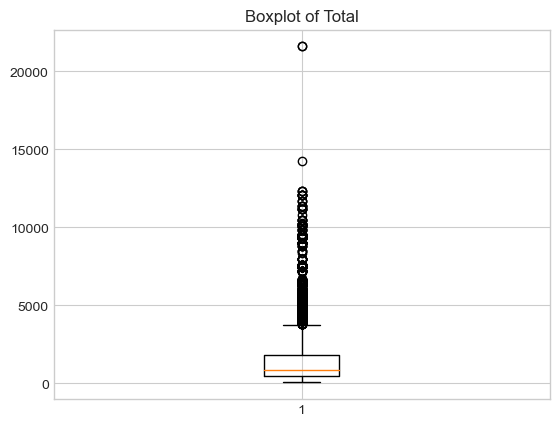

In [44]:
#distribusi

plt.boxplot(dfh['total'])
plt.title('Boxplot of Total')
plt.show()

In [45]:
ganti = dfh

In [46]:
ganti.to_csv('bike.csv', index= False)